In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("БАНКОВСКИЕ РЕКОМЕНДАЦИИ - EDA АНАЛИЗ")
print("=" * 80)

# 1. ЗАГРУЗКА ДАННЫХ
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 40)

# Загрузка данных (предполагаем, что файл называется train.csv)
# Если файл имеет другое название, измените эту строку
df = pd.read_csv('train_ver2.csv', low_memory=False)
print(f"✓ Данные успешно загружены")
print(f"  Размер данных: {df.shape[0]:,} строк, {df.shape[1]} столбцов")


БАНКОВСКИЕ РЕКОМЕНДАЦИИ - EDA АНАЛИЗ

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
✓ Данные успешно загружены
  Размер данных: 13,647,309 строк, 48 столбцов


In [2]:
pd.set_option('display.max_rows', None)


In [3]:
df.dtypes

fecha_dato                object
ncodpers                   int64
ind_empleado              object
pais_residencia           object
sexo                      object
age                       object
fecha_alta                object
ind_nuevo                float64
antiguedad                object
indrel                   float64
ult_fec_cli_1t            object
indrel_1mes               object
tiprel_1mes               object
indresi                   object
indext                    object
conyuemp                  object
canal_entrada             object
indfall                   object
tipodom                  float64
cod_prov                 float64
nomprov                   object
ind_actividad_cliente    float64
renta                    float64
segmento                  object
ind_ahor_fin_ult1          int64
ind_aval_fin_ult1          int64
ind_cco_fin_ult1           int64
ind_cder_fin_ult1          int64
ind_cno_fin_ult1           int64
ind_ctju_fin_ult1          int64
ind_ctma_f

In [4]:
# 2. ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ
print("\n2. ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ")
print("-" * 40)

# Первые строки
print("\nПервые 3 строки данных:")
print(df.head(3))

# Информация о типах данных
print("\nИнформация о типах данных:")
df.info()

# Основные статистики числовых колонок
print("\nОсновные статистики числовых признаков:")
print(df.describe().round(2))


2. ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ
----------------------------------------

Первые 3 строки данных:
   fecha_dato  ncodpers ind_empleado pais_residencia sexo  age  fecha_alta  \
0  2015-01-28   1375586            N              ES    H   35  2015-01-12   
1  2015-01-28   1050611            N              ES    V   23  2012-08-10   
2  2015-01-28   1050612            N              ES    V   23  2012-08-10   

   ind_nuevo antiguedad  indrel ult_fec_cli_1t indrel_1mes tiprel_1mes  \
0        0.0          6     1.0            NaN         1.0           A   
1        0.0         35     1.0            NaN           1           I   
2        0.0         35     1.0            NaN           1           I   

  indresi indext conyuemp canal_entrada indfall  tipodom  cod_prov  \
0       S      N      NaN           KHL       N      1.0      29.0   
1       S      S      NaN           KHE       N      1.0      13.0   
2       S      N      NaN           KHE       N      1.0      13.0   

       nomprov 

In [7]:
# . ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ
print("\n3. ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ")
print("-" * 40)

# Преобразуем даты
date_columns = ['fecha_dato', 'fecha_alta', 'ult_fec_cli_1t']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"✓ Преобразована колонка {col} в datetime")

# Преобразуем возраст и стаж в числовой тип, обрабатывая ошибки
if 'age' in df.columns:
    # Пробуем преобразовать в числовой, ошибки станут NaN
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    print(f"✓ Преобразована колонка age в numeric. Найдено {df['age'].isnull().sum()} пропусков.")

if 'antiguedad' in df.columns:
    # Аналогично для стажа
    df['antiguedad'] = pd.to_numeric(df['antiguedad'], errors='coerce')
    print(f"✓ Преобразована колонка antiguedad в numeric. Найдено {df['antiguedad'].isnull().sum()} пропусков.")


3. ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ
----------------------------------------
✓ Преобразована колонка fecha_dato в datetime
✓ Преобразована колонка fecha_alta в datetime
✓ Преобразована колонка ult_fec_cli_1t в datetime
✓ Преобразована колонка age в numeric. Найдено 27734 пропусков.
✓ Преобразована колонка antiguedad в numeric. Найдено 27734 пропусков.


In [8]:
# 3. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
print("\n3. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
print("-" * 40)

# Количество пропусков по колонкам
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Колонка': missing_values.index,
    'Пропусков': missing_values.values,
    'Процент': missing_percent.values
}).sort_values('Процент', ascending=False)

print("Колонки с пропусками (первые 20):")
print(missing_df[missing_df['Пропусков'] > 0].head(20))

# Визуализация пропусков
# plt.figure(figsize=(12, 6))
# missing_cols = missing_df[missing_df['Процент'] > 0]
# plt.bar(missing_cols['Колонка'][:20], missing_cols['Процент'][:20])
# plt.xticks(rotation=90)
# plt.title('Процент пропущенных значений по колонкам (первые 20)')
# plt.ylabel('Процент пропусков (%)')
# plt.tight_layout()
# plt.savefig('missing_values.png', dpi=100)
# plt.show()



3. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
----------------------------------------
Колонки с пропусками (первые 20):
            Колонка  Пропусков    Процент
15         conyuemp   13645501  99.986752
10   ult_fec_cli_1t   13622516  99.818330
22            renta    2794375  20.475648
23         segmento     189368   1.387585
16    canal_entrada     186126   1.363829
11      indrel_1mes     149781   1.097513
12      tiprel_1mes     149781   1.097513
19         cod_prov      93591   0.685784
20          nomprov      93591   0.685784
4              sexo      27804   0.203732
18          tipodom      27735   0.203227
9            indrel      27734   0.203220
8        antiguedad      27734   0.203220
3   pais_residencia      27734   0.203220
5               age      27734   0.203220
2      ind_empleado      27734   0.203220
6        fecha_alta      27734   0.203220
7         ind_nuevo      27734   0.203220
14           indext      27734   0.203220
13          indresi      27734   0.203220


In [9]:

# 4. АНАЛИЗ ВРЕМЕННЫХ ПЕРЕМЕННЫХ
print("\n4. АНАЛИЗ ВРЕМЕННЫХ ПЕРЕМЕННЫХ")
print("-" * 40)

# Преобразуем даты
if 'fecha_dato' in df.columns:
    df['fecha_dato'] = pd.to_datetime(df['fecha_dato'])
    print(f"✓ Датасет охватывает период: {df['fecha_dato'].min()} - {df['fecha_dato'].max()}")
    print(f"  Количество уникальных месяцев: {df['fecha_dato'].dt.to_period('M').nunique()}")

if 'fecha_alta' in df.columns:
    df['fecha_alta'] = pd.to_datetime(df['fecha_alta'], errors='coerce')
    print(f"✓ Диапазон дат регистрации клиентов: {df['fecha_alta'].min()} - {df['fecha_alta'].max()}")

# Количество записей по месяцам
# if 'fecha_dato' in df.columns:
#     monthly_counts = df['fecha_dato'].dt.to_period('M').value_counts().sort_index()
    
#     plt.figure(figsize=(12, 4))
#     monthly_counts.plot(kind='bar')
#     plt.title('Количество записей по месяцам')
#     plt.xlabel('Месяц')
#     plt.ylabel('Количество записей')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.savefig('monthly_counts.png', dpi=100)
#     plt.show()



4. АНАЛИЗ ВРЕМЕННЫХ ПЕРЕМЕННЫХ
----------------------------------------
✓ Датасет охватывает период: 2015-01-28 00:00:00 - 2016-05-28 00:00:00
  Количество уникальных месяцев: 17
✓ Диапазон дат регистрации клиентов: 1995-01-16 00:00:00 - 2016-05-31 00:00:00


In [10]:

# 5. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ
print("\n5. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ")
print("-" * 40)

# Выбираем категориальные колонки
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Всего категориальных переменных: {len(categorical_cols)}")
print("Список категориальных переменных:", categorical_cols)

# Анализ уникальных значений для каждой категориальной переменной
for col in categorical_cols[:10]:  # Анализируем первые 10
    unique_vals = df[col].nunique()
    print(f"\n{col}:")
    print(f"  Уникальных значений: {unique_vals}")
    if unique_vals <= 15:
        value_counts = df[col].value_counts(dropna=False)
        print("  Распределение:")
        for val, count in value_counts.items():
            percent = (count / len(df)) * 100
            print(f"    {val}: {count:,} ({percent:.1f}%)")
    else:
        print(f"  Слишком много уникальных значений для отображения")



5. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ
----------------------------------------
Всего категориальных переменных: 12
Список категориальных переменных: ['ind_empleado', 'pais_residencia', 'sexo', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp', 'canal_entrada', 'indfall', 'nomprov', 'segmento']

ind_empleado:
  Уникальных значений: 5
  Распределение:
    N: 13,610,977 (99.7%)
    nan: 27,734 (0.2%)
    B: 3,566 (0.0%)
    F: 2,523 (0.0%)
    A: 2,492 (0.0%)
    S: 17 (0.0%)

pais_residencia:
  Уникальных значений: 118
  Слишком много уникальных значений для отображения

sexo:
  Уникальных значений: 2
  Распределение:
    V: 7,424,252 (54.4%)
    H: 6,195,253 (45.4%)
    nan: 27,804 (0.2%)

indrel_1mes:
  Уникальных значений: 9
  Распределение:
    1.0: 9,133,383 (66.9%)
    1: 4,357,298 (31.9%)
    nan: 149,781 (1.1%)
    3.0: 2,780 (0.0%)
    3: 1,570 (0.0%)
    P: 874 (0.0%)
    2.0: 740 (0.0%)
    2: 577 (0.0%)
    4.0: 223 (0.0%)
    4: 83 (0.0%)

tiprel_1mes:
  Уникальны


6. АНАЛИЗ ЧИСЛОВЫХ ПЕРЕМЕННЫХ
----------------------------------------
Всего числовых переменных: 33

age:
  Min: 2.0
  Max: 164.0
  Mean: 40.18146491355274
  Median: 39.0
  Стандартное отклонение: 17.185086968822453
  Пропусков: 27,734 (0.2%)

antiguedad:
  Min: -999999.0
  Max: 256.0
  Mean: 76.59194064425652
  Median: 50.0
  Стандартное отклонение: 1671.8065468734276
  Пропусков: 27,734 (0.2%)

renta:
  Min: 1202.73
  Max: 28894395.51
  Mean: 134254.31823814093
  Median: 101850.0
  Стандартное отклонение: 230620.23882188636
  Пропусков: 2,794,375 (20.5%)


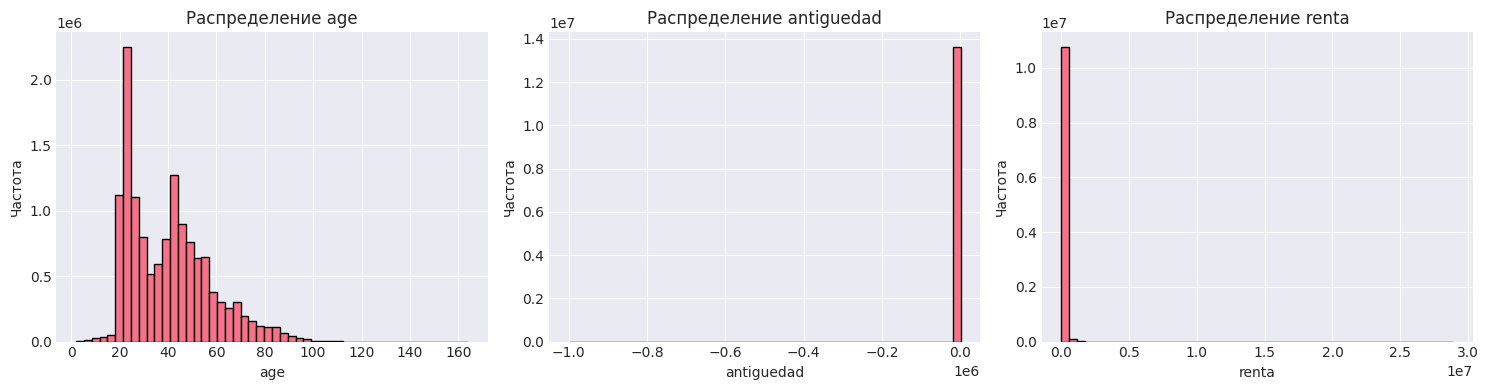

In [11]:
# 6. АНАЛИЗ ЧИСЛОВЫХ ПЕРЕМЕННЫХ
print("\n6. АНАЛИЗ ЧИСЛОВЫХ ПЕРЕМЕННЫХ")
print("-" * 40)

# Выбираем числовые колонки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Всего числовых переменных: {len(numeric_cols)}")

# Анализ распределения ключевых числовых признаков
key_numeric = ['age', 'antiguedad', 'renta']

for col in key_numeric:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Min: {df[col].min()}")
        print(f"  Max: {df[col].max()}")
        print(f"  Mean: {df[col].mean()}")
        print(f"  Median: {df[col].median()}")
        print(f"  Стандартное отклонение: {df[col].std()}")
        print(f"  Пропусков: {df[col].isnull().sum():,} ({df[col].isnull().sum()/len(df)*100:.1f}%)")

# Визуализация распределения ключевых числовых признаков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(key_numeric):
    if col in df.columns:
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black')
        axes[idx].set_title(f'Распределение {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=100)
plt.show()



7. АНАЛИЗ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ (БАНКОВСКИХ ПРОДУКТОВ)
----------------------------------------
Всего продуктов (целевых переменных): 24

Топ-10 самых популярных продуктов:
          Продукт   Клиентов    Процент
2             cco  8945588.0  65.548366
7            ctop  1760616.0  12.900829
23    recibo_ult1  1745712.0  12.791621
12           ecue  1129227.0   8.274357
4             cno  1103620.0   8.086722
22  nom_pens_ult1   810085.0   5.935859
21    nomina_ult1   745961.0   5.465993
17           reca   716980.0   5.253636
18           tjcr   605786.0   4.438868
8            ctpp   591008.0   4.330583

Топ-10 самых редких продуктов:
   Продукт  Клиентов   Процент
5     ctju  129297.0  0.947418
15    plan  125159.0  0.917097
14     hip   80336.0  0.588658
20     viv   52511.0  0.384772
16    pres   35857.0  0.262740
9     deco   24275.0  0.177874
10    deme   22668.0  0.166099
3     cder    5376.0  0.039392
0     ahor    1396.0  0.010229
1     aval     316.0  0.002315


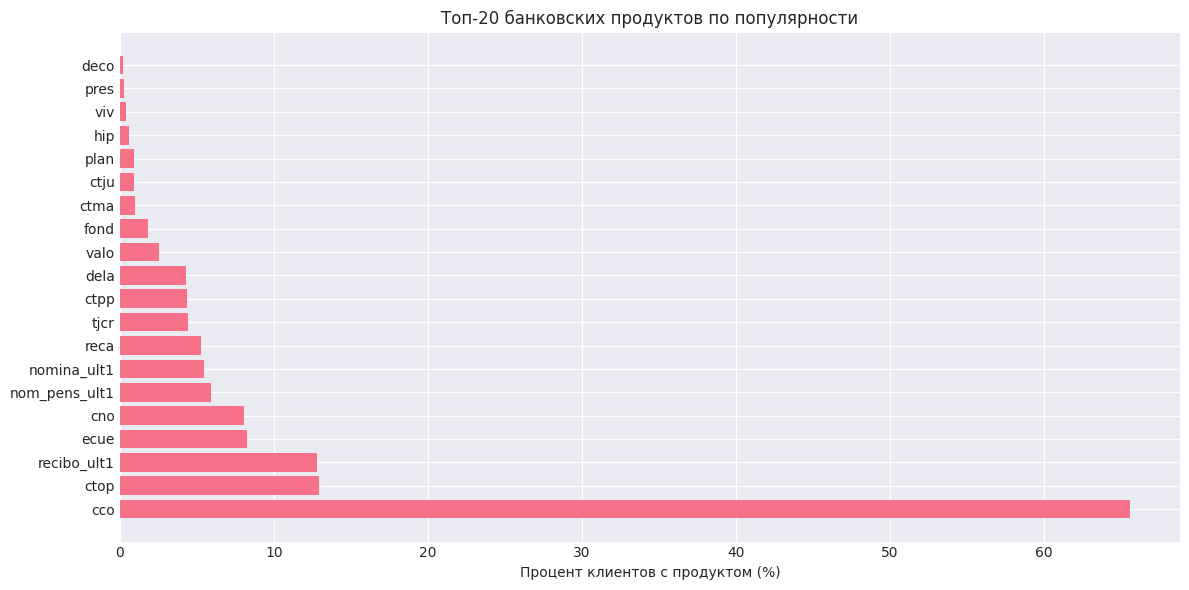

In [12]:

# 7. АНАЛИЗ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ (БАНКОВСКИХ ПРОДУКТОВ)
print("\n7. АНАЛИЗ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ (БАНКОВСКИХ ПРОДУКТОВ)")
print("-" * 40)

# Найдем колонки с продуктами (целевые переменные)
product_cols = [col for col in df.columns if col.startswith('ind_') and col.endswith('_ult1')]
print(f"Всего продуктов (целевых переменных): {len(product_cols)}")

# Процент клиентов с каждым продуктом
product_stats = []
for col in product_cols:
    if col in df.columns:
        clients_with_product = df[col].sum()
        percent = (clients_with_product / len(df)) * 100
        product_stats.append({
            'Продукт': col.replace('ind_', '').replace('_fin_ult1', ''),
            'Клиентов': clients_with_product,
            'Процент': percent
        })

product_stats_df = pd.DataFrame(product_stats).sort_values('Процент', ascending=False)
print("\nТоп-10 самых популярных продуктов:")
print(product_stats_df.head(10).to_string())

print("\nТоп-10 самых редких продуктов:")
print(product_stats_df.tail(10).to_string())

# Визуализация популярности продуктов
plt.figure(figsize=(12, 6))
plt.barh(product_stats_df['Продукт'][:20], product_stats_df['Процент'][:20])
plt.title('Топ-20 банковских продуктов по популярности')
plt.xlabel('Процент клиентов с продуктом (%)')
plt.tight_layout()
plt.savefig('product_popularity.png', dpi=100)
plt.show()



8. АНАЛИЗ УНИКАЛЬНЫХ КЛИЕНТОВ
----------------------------------------
Количество уникальных клиентов: 956,645
Количество записей на клиента: 14.27


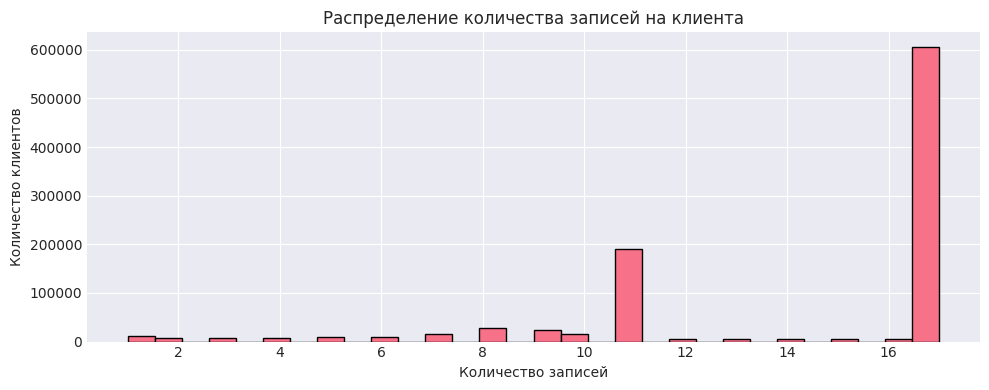

In [13]:

# 8. АНАЛИЗ УНИКАЛЬНЫХ КЛИЕНТОВ
print("\n8. АНАЛИЗ УНИКАЛЬНЫХ КЛИЕНТОВ")
print("-" * 40)

if 'ncodpers' in df.columns:
    unique_clients = df['ncodpers'].nunique()
    print(f"Количество уникальных клиентов: {unique_clients:,}")
    print(f"Количество записей на клиента: {len(df) / unique_clients:.2f}")
    
    # Распределение количества записей на клиента
    client_record_counts = df['ncodpers'].value_counts()
    
    plt.figure(figsize=(10, 4))
    plt.hist(client_record_counts.values, bins=30, edgecolor='black')
    plt.title('Распределение количества записей на клиента')
    plt.xlabel('Количество записей')
    plt.ylabel('Количество клиентов')
    plt.tight_layout()
    plt.savefig('client_records_distribution.png', dpi=100)
    plt.show()



9. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
----------------------------------------


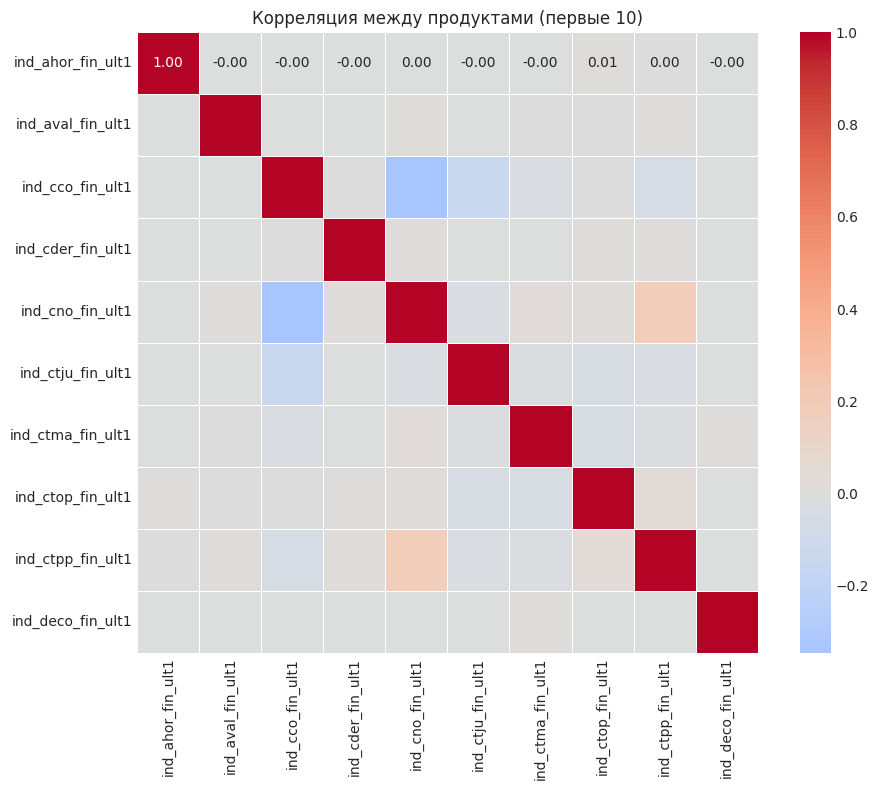

In [14]:

# 9. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
print("\n9. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("-" * 40)

# Корреляция между продуктами (только первые 10 для наглядности)
if len(product_cols) > 10:
    product_corr = df[product_cols[:10]].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(product_corr, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5)
    plt.title('Корреляция между продуктами (первые 10)')
    plt.tight_layout()
    plt.savefig('product_correlation.png', dpi=100)
    plt.show()


In [15]:

# 10. АНАЛИЗ ВЫБРОСОВ
print("\n10. АНАЛИЗ ВЫБРОСОВ В КЛЮЧЕВЫХ ПЕРЕМЕННЫХ")
print("-" * 40)

# Анализ выбросов в возрасте и доходе
for col in ['age', 'renta']:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"\n{col}:")
        print(f"  Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Количество выбросов: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")
        if len(outliers) > 0:
            print(f"  Минимальное значение выброса: {outliers[col].min():.2f}")
            print(f"  Максимальное значение выброса: {outliers[col].max():.2f}")



10. АНАЛИЗ ВЫБРОСОВ В КЛЮЧЕВЫХ ПЕРЕМЕННЫХ
----------------------------------------

age:
  Границы выбросов: [-15.00, 89.00]
  Количество выбросов: 113,291 (0.8%)
  Минимальное значение выброса: 90.00
  Максимальное значение выброса: 164.00

renta:
  Границы выбросов: [-62156.49, 286823.43]
  Количество выбросов: 659,391 (4.8%)
  Минимальное значение выброса: 286833.84
  Максимальное значение выброса: 28894395.51
